# 5 — QB — `HighFrequencyImputer` pas à pas

Ce notebook **audite** `HighFrequencyImputer`
(`tsforecast/frequency/high_frequency_imputer.py`, la v2, renommée sans suffixe
au prompt 16) sur **un seul jeu** : `PANEL-X`
([SPEC] `high_frequency_imputer2_architecture.md` §2.6), reconstruit par la
**même fonction** que la fixture `panel_reference_full`
(`tests/frequency/conftest.py::_build_panel_reference`).

**Règle permanente.** Aucune cellule ne recalcule une imputation à la main :
tout affichage lit `imputer.imputation_plan_`, les attributs suffixés `_`, ou
appelle une **méthode réelle** de la classe ou de ses composants. L'estimateur
espion (`_SpyEstimator`, repris de la suite de tests) retient
`fit_X_` / `fit_y_` / `predict_X_`, ce qui rend `X_train`, `y_train` et `X_pred`
lisibles **sur le plan lui-même**.

**Le jeu unique et ses projections.** `PANEL-X` porte simultanément les six
colonnes `m1, q1, a1, a2, climat_affaires, v`. Il porte donc à la fois la
feature structurellement absente pour une entité (`climat_affaires` / `IT`,
§4.5) et la colonne à fréquence hétérogène par entité (`v` : annuelle `FR`,
trimestrielle `DE`, mensuelle `IT`, §2.5). Les **valeurs d'or chiffrées** du
[SPEC] (§4.7, §5.5, §5.8) sont énoncées sur les jeux **isolés** ; chaque fois
que le notebook en vérifie une, il repasse **explicitement** par la projection
correspondante :

| Projection | Définition | Rôle |
|---|---|---|
| `TS` | `PANEL-X.loc['FR', ['m1','q1','a1','a2']]` | valeurs d'or §4.7 / §5.5 |
| `PANEL-F` | `PANEL-X[['m1','q1','v']]` | mutualisation §5.8 |
| `PANEL` | `PANEL-X[['m1','q1','a1','a2','climat_affaires']]` | `covariate_eligibility` §4.5 |

Sur le **frame complet**, `v` devient covariable de `a1`/`a2` et réciproquement :
le plan gagne des étapes et les `X_train` **ne sont plus** ceux du §5.5. C'est
attendu — c'est précisément ce qu'illustre le jeu unifié.

## 1 — Imports, jeu unique et outillage d'audit

In [1]:
"""Imports et configuration d'affichage."""
import importlib.util
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import LinearRegression

from tsforecast.frequency import HighFrequencyImputer
from tsforecast.frequency.provenance import resolve_model_provenance

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 120)

NOTEBOOK_START = time.perf_counter()
print("Modules importés.")

Modules importés.


In [2]:
"""Jeu unique `PANEL-X` : reconstruit par la fonction même de la fixture.

`tests/frequency/conftest.py::_build_panel_reference` est le constructeur
canonique du §2.6. On le charge par son chemin (le fichier n'est pas un module
importable), sans dupliquer une ligne de génération.
"""
def _repo_root() -> Path:
    here = Path.cwd()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("racine du dépôt introuvable")


_conftest_path = _repo_root() / "tests" / "frequency" / "conftest.py"
_spec = importlib.util.spec_from_file_location("_hfi_conftest", _conftest_path)
_conftest = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_conftest)

PANEL_X = _conftest._build_panel_reference()

# Projections strictes (§2.6) — chacune est un sous-jeu de colonnes / d'entités.
TS = PANEL_X.loc["FR", ["m1", "q1", "a1", "a2"]]
PANEL_F = PANEL_X[["m1", "q1", "v"]]
PANEL = PANEL_X[["m1", "q1", "a1", "a2", "climat_affaires"]]

print("PANEL-X :", PANEL_X.shape, "| colonnes :", list(PANEL_X.columns))
print("TS      :", TS.shape, "| index :", type(TS.index).__name__)
print("PANEL-F :", PANEL_F.shape)
PANEL_X.groupby(level=0).apply(lambda g: g.notna().sum()).T

PANEL-X : (108, 6) | colonnes : ['m1', 'q1', 'a1', 'a2', 'climat_affaires', 'v']
TS      : (36, 4) | index : DatetimeIndex
PANEL-F : (108, 3)


country,DE,FR,IT
m1,36,36,36
q1,12,12,12
a1,3,3,3
a2,3,3,3
climat_affaires,36,36,0
v,12,3,36


In [3]:
"""Estimateur espion — repris de `tests/frequency/test_high_frequency_imputer.py`.

Il tolère les NaN, prédit la moyenne apprise, et RETIENT ce que chaque appel
lui a montré : `fit_X_`, `fit_y_`, et la liste `predict_X_` des trames de
prédiction. C'est ce qui rend `X_train` / `y_train` / `X_pred` lisibles
directement sur `step.model`, sans recalcul.
"""
class _SpyEstimator(BaseEstimator, RegressorMixin):
    """Estimateur espion tolérant les NaN, prédisant une constante."""

    n_fits = 0

    def __init__(self, constant: float = 1.0):
        self.constant = constant

    def fit(self, X, y):
        """Retient le jeu d'entraînement et la moyenne de la cible."""
        type(self).n_fits += 1
        self.fit_X_ = X.copy()
        self.fit_y_ = y.copy()
        self.predict_X_ = []
        values = np.asarray(y, dtype=float)
        finite = values[~np.isnan(values)]
        self.mean_ = float(finite.mean()) if finite.size else 0.0
        return self

    def predict(self, X):
        """Retient la trame de prédiction et rend la moyenne apprise."""
        if not hasattr(self, "predict_X_"):
            self.predict_X_ = []
        self.predict_X_.append(X.copy())
        return np.full(len(X), self.mean_)


def fit_spy(data, **params):
    """Ajuste un imputeur muni de l'espion, avertissements silencés."""
    _SpyEstimator.n_fits = 0
    base = dict(target_frequency="M", estimator=_SpyEstimator())
    base.update(params)
    imputer = HighFrequencyImputer(**base)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        imputer.fit(data)
    return imputer

In [4]:
"""Fonctions d'affichage — AUCUNE logique métier, seulement de la mise en forme."""
def show(obj, title=None):
    """Affiche type, forme, NaN par colonne et un aperçu d'un objet pandas."""
    if title:
        print(f"\n>>> {title}")
    if isinstance(obj, pd.DataFrame):
        print(f"  DataFrame {obj.shape} | NaN/col : {obj.isna().sum().to_dict()}")
        print(obj.head(8).to_string())
    elif isinstance(obj, pd.Series):
        print(f"  Series len={len(obj)} name={obj.name!r} | NaN={int(obj.isna().sum())}")
        print(obj.head(10).to_string())
    else:
        print(f"  {obj!r}")


def entities_of(index):
    """Rend, pour chaque ligne d'un index, sa clé d'entité (`()` en série)."""
    if not isinstance(index, pd.MultiIndex):
        return [()] * len(index)
    return [tuple(key[:-1]) for key in index]


def filled_dates_by_entity(frame, column):
    """Rend, par entité, l'ensemble des dates où `column` est renseignée."""
    idx = frame.index[frame[column].notna().to_numpy()]
    out = {}
    for key in idx:
        if isinstance(idx, pd.MultiIndex):
            out.setdefault(tuple(key[:-1]), set()).add(key[-1])
        else:
            out.setdefault((), set()).add(key)
    return out

## 2 — Le jeu `PANEL-X` et ses trois projections

`PANEL-X` : trois entités `FR` / `DE` / `IT`, index mensuel fin de mois
2021-01-31 → 2023-12-31 (36 dates × 3 = 108 lignes). Toutes les colonnes sont
**additives** (une valeur annuelle est la somme de ses sous-périodes).
`target_frequency='M'`.

- `m1` : mensuelle dense, `100 + rang`, identique aux trois entités ;
- `q1` : trimestrielle, 12 ancres (`10 × k`), identique ;
- `a1` / `a2` : annuelles, 3 ancres — valeurs d'or **120 / 132 / 150** et
  **60 / 66 / 72** (§2.2) ;
- `climat_affaires` : mensuelle pour `FR` et `DE`, **jamais observée pour `IT`**
  (§4.5) — bruit gaussien, aucune valeur d'or ;
- `v` : **annuelle pour `FR`**, **trimestrielle pour `DE`**, **mensuelle pour
  `IT`** (§2.5), les trois portant le même total annuel 120 / 132 / 150.

In [5]:
for name, data in [("PANEL-X", PANEL_X), ("TS (proj. FR)", TS), ("PANEL-F (proj.)", PANEL_F)]:
    show(data, name)


>>> PANEL-X
  DataFrame (108, 6) | NaN/col : {'m1': 0, 'q1': 72, 'a1': 99, 'a2': 99, 'climat_affaires': 36, 'v': 57}
                       m1    q1  a1  a2  climat_affaires     v
country date                                                  
DE      2021-01-31  100.0   NaN NaN NaN       100.067982   NaN
        2021-02-28  101.0   NaN NaN NaN       102.082671   NaN
        2021-03-31  102.0  10.0 NaN NaN       100.375558  28.0
        2021-04-30  103.0   NaN NaN NaN       103.934581   NaN
        2021-05-31  104.0   NaN NaN NaN        98.887536   NaN
        2021-06-30  105.0  20.0 NaN NaN        99.513831  30.0
        2021-07-31  106.0   NaN NaN NaN        99.236792   NaN
        2021-08-31  107.0   NaN NaN NaN       101.854245   NaN

>>> TS (proj. FR)
  DataFrame (36, 4) | NaN/col : {'m1': 0, 'q1': 24, 'a1': 33, 'a2': 33}
               m1    q1  a1  a2
date                           
2021-01-31  100.0   NaN NaN NaN
2021-02-28  101.0   NaN NaN NaN
2021-03-31  102.0  10.0 NaN NaN
2

In [6]:
"""Identités de projection — vérifiées (elles sont testées dans
`tests/frequency/test_reference_datasets.py`)."""
print("TS      == PANEL_X.loc['FR', [...]]           :",
      TS.equals(PANEL_X.loc["FR", ["m1", "q1", "a1", "a2"]]))
print("PANEL_F == PANEL_X[['m1','q1','v']]           :",
      PANEL_F.equals(PANEL_X[["m1", "q1", "v"]]))
print("v de FR (ancres annuelles)  :", PANEL_X.loc["FR", "v"].dropna().tolist())
print("v de DE (ancres trimestre)  :", PANEL_X.loc["DE", "v"].dropna().tolist())
print("v de IT (mensuelle, 3 vals) :", sorted(PANEL_X.loc["IT", "v"].dropna().unique().tolist()))

TS      == PANEL_X.loc['FR', [...]]           : True
PANEL_F == PANEL_X[['m1','q1','v']]           : True
v de FR (ancres annuelles)  : [120.0, 132.0, 150.0]
v de DE (ancres trimestre)  : [28.0, 30.0, 31.0, 31.0, 31.0, 33.0, 34.0, 34.0, 36.0, 37.0, 38.0, 39.0]
v de IT (mensuelle, 3 vals) : [10.0, 11.0, 12.5]


## 3 — `fit` phase par phase sur `PANEL-X`

Configuration de référence du pas-à-pas :
`covariate_strategy='model'`, `fit_predict_order='frequency'`,
`impute_intermediate_frequencies=True`, `scale_features='constant'`,
`aggregation_constraint='sum'`. `impute_intermediate_frequencies=True` fait
apparaître les souillures de cible (`target_taint`) et donc les familles
`MODEL_ON_IMPUTED_*` — la section 7 balaie systématiquement les autres cas.

Chaque phase est nommée comme dans [SPEC] §12.3. Le pas-à-pas **appelle `fit`**
puis lit l'attribut que chaque phase produit — il ne réexécute pas les phases
une à une (ce serait dupliquer la boucle de cascade).

In [7]:
REF = fit_spy(
    PANEL_X,
    covariate_strategy="model",
    fit_predict_order="frequency",
    impute_intermediate_frequencies=True,
    scale_features="constant",
    aggregation_constraint="sum",
)
print("fit terminé —", len(REF.imputation_plan_), "étapes de plan,",
      _SpyEstimator.n_fits, "ajustements d'estimateur.")

fit terminé — 8 étapes de plan, 7 ajustements d'estimateur.


### PHASE 0 — Setup

Purge de l'état d'un `transform` précédent, colonnes, détection panel,
alignement/nommage de `y`, **détection des fréquences par `(entité, colonne)`**,
normalisation/validation de `target_frequency`, classification des variables.

In [8]:
print("is_panel_        :", REF.is_panel_)
print("entities_        :", REF.entities_)
print("target_column_   :", REF.target_column_)
print("feature_columns_ :", REF.feature_columns_)
print("\neffective_target_frequency_ :", REF.effective_target_frequency_)
print("\ndetected_frequencies_ (par (entité, colonne)) :")
for key, freq in sorted(REF.detected_frequencies_.items()):
    print(f"    {key} -> {freq}")
print("\nvariable_categories_ :")
for cat, keys in REF.variable_categories_.items():
    print(f"    {cat:11s} : {keys}")

is_panel_        : True
entities_        : [('DE',), ('FR',), ('IT',)]
target_column_   : None
feature_columns_ : ['m1', 'q1', 'a1', 'a2', 'climat_affaires', 'v']

effective_target_frequency_ : {('DE',): 'M', ('IT',): 'M', ('FR',): 'M'}

detected_frequencies_ (par (entité, colonne)) :
    ('DE', 'a1') -> Y
    ('DE', 'a2') -> Y
    ('DE', 'climat_affaires') -> M
    ('DE', 'm1') -> M
    ('DE', 'q1') -> Q
    ('DE', 'v') -> Q
    ('FR', 'a1') -> Y
    ('FR', 'a2') -> Y
    ('FR', 'climat_affaires') -> M
    ('FR', 'm1') -> M
    ('FR', 'q1') -> Q
    ('FR', 'v') -> Y
    ('IT', 'a1') -> Y
    ('IT', 'a2') -> Y
    ('IT', 'm1') -> M
    ('IT', 'q1') -> Q
    ('IT', 'v') -> M

variable_categories_ :
    aggregate   : []
    impute      : [('DE', 'q1'), ('DE', 'a1'), ('DE', 'a2'), ('DE', 'v'), ('FR', 'q1'), ('FR', 'a1'), ('FR', 'a2'), ('FR', 'v'), ('IT', 'q1'), ('IT', 'a1'), ('IT', 'a2')]
    target_freq : [('DE', 'm1'), ('DE', 'climat_affaires'), ('FR', 'm1'), ('FR', 'climat_affaires'), 

Lecture : `v` est classée `impute` pour `FR` (annuelle → mensuelle) et `DE`
(trimestrielle → mensuelle), mais `target_freq` pour `IT`, qui l'observe déjà
au pas mensuel. `climat_affaires` est `target_freq` partout où elle est
observée et **absente de `detected_frequencies_` pour `IT`** — un couple
`(IT, climat_affaires)` sans fréquence détectable, écarté de la classification.

In [9]:
print("Couples (entité, colonne) jamais observés (écartés) :", REF._undetected_frequencies_)

Couples (entité, colonne) jamais observés (écartés) : (('IT', 'climat_affaires'),)


### PHASE 1 — Fenêtres : les trois masques

`ImputationWindowCalculator` produit trois masques distincts — `strict`,
`imputation`, `training` (§7). Chacun est lu par son appelant sous un `kind`
nommé. Sur panel, ce sont des `pd.Series` à MultiIndex `(entité, date)`.

In [10]:
for attr in ["strict_window_mask_", "imputation_window_mask_", "training_window_mask_"]:
    mask = getattr(REF, attr)
    per_entity = mask.groupby(level=0).sum().to_dict()
    print(f"{attr:26s} : {int(mask.sum())} lignes True   par entité : {per_entity}")
print("\nBornes lisibles :")
print("  imputation_window_ :", REF.imputation_window_)
print("  training_window_   :", REF.training_window_)

strict_window_mask_        : 72 lignes True   par entité : {'DE': 36, 'FR': 36, 'IT': 0}
imputation_window_mask_    : 72 lignes True   par entité : {'DE': 36, 'FR': 36, 'IT': 0}
training_window_mask_      : 72 lignes True   par entité : {'DE': 36, 'FR': 36, 'IT': 0}

Bornes lisibles :
  imputation_window_ : {('DE',): (Timestamp('2021-01-31 00:00:00'), Timestamp('2023-12-31 00:00:00')), ('FR',): (Timestamp('2021-01-31 00:00:00'), Timestamp('2023-12-31 00:00:00')), ('IT',): (None, None)}
  training_window_   : {('DE',): (Timestamp('2021-01-31 00:00:00'), Timestamp('2023-12-31 00:00:00')), ('FR',): (Timestamp('2021-01-31 00:00:00'), Timestamp('2023-12-31 00:00:00')), ('IT',): (None, None)}


`IT` n'apparaît **pas** dans la fenêtre stricte : sa colonne `climat_affaires`
n'a aucune observation, donc aucune date où *toutes* les colonnes sont couvertes.
Conséquence directe, mesurée en section 6 : sur le frame complet, aucune cellule
de `IT` n'est imputée pour `q1` / `a1` / `a2`.

### PHASE 2 — Transformateur additif

`additive_transformer=None` ici : la phase est un no-op. Elle sert normalement
à rendre les colonnes additives (log, différenciation…) avant la cascade,
`additive_transformer` étant l'unique échappatoire à l'hypothèse d'additivité
de la classe (§2.2, D20).

In [11]:
print("additive_transformer_ :", REF.additive_transformer_)

additive_transformer_ : None


### PHASE 3 — Progression de fréquences (§5.2)

Liste ordonnée des `f_stage`, de la plus basse à la plus haute. Sur panel,
chaque étape est un `{entité: fréquence}` ne liant que les entités que le groupe
de fréquence cible traverse (D31).

In [12]:
for i, stage in enumerate(REF.frequency_progression_):
    print(f"  étape {i} : label={REF._stage_frequency_label(stage)!r}  |  {stage}")

  étape 0 : label='Q'  |  {('DE',): 'Q', ('IT',): 'Q', ('FR',): 'Q'}
  étape 1 : label='M'  |  {('DE',): 'M', ('IT',): 'M', ('FR',): 'M'}


### PHASE 4 — Provenance

`ImputationProvenanceTracker` initialisé **après** le transformateur additif
(B8) : chaque cellule non-NaN de `X_work` vaut `ORIGINAL`, chaque NaN reste
`None`. En fin de `fit` cette matrice devient `imputation_provenance_`.

In [13]:
prov = REF.imputation_provenance_
prov_str = prov.map(lambda x: x.value if hasattr(x, "value") else ("—" if pd.isna(x) else str(x)))
print("Répartition finale par colonne (comptes) :")
for col in prov_str.columns:
    print(f"  {col:16s} : {prov_str[col].value_counts().to_dict()}")

Répartition finale par colonne (comptes) :
  m1               : {'original': 108}
  q1               : {'model_on_imputed': 72, '—': 24, 'original': 12}
  a1               : {'model_on_imputed_both': 72, '—': 33, 'original': 3}
  a2               : {'model_on_imputed_both': 72, '—': 33, 'original': 3}
  climat_affaires  : {'original': 72, '—': 36}
  v                : {'model_on_imputed_both': 72, 'original': 36}


### PHASE 5 — Exécution des étapes

Pour chaque étape de la progression : frame d'étape (5a), variables imputables
et ordre (5b, seulement sous `covariate_strategy='model'`), puis une passe par
variable (5c) — jeu d'entraînement **mutualisé**, voie de matérialisation
décidée sur la grille de prédiction et imposée aux deux grilles, souillures,
mise à l'échelle, **un seul ajustement par (étape, variable)** partagé par ses
groupes de fréquence source. Le détail par étape est en **section 5**.

In [14]:
print("imputation_order_ (par étape, sous 'model') :")
for stage, order in REF.imputation_order_.items():
    print(f"  {stage} : {order}")
print("\nimputation_plan_.to_diagnostic_frame() :")
REF.imputation_plan_.to_diagnostic_frame()

imputation_order_ (par étape, sous 'model') :
  Q : ['v', 'a1', 'a2']
  M : ['v', 'a1', 'a2', 'q1']

imputation_plan_.to_diagnostic_frame() :


,stage,variable,n_features,covariate_taint,target_taint,emitted_provenance,is_fallback,interpolation_method,interpolation_anchor,materialization,training_blocks
0,Q,v,5,interpolated,none,model_on_interpolated,False,linear,None,"m1=aggregate, q1=identity, a1=interpolate, a2=...","DE=Q, FR=Y, IT=M"
1,Q,a1,5,imputed,none,model_on_imputed,False,linear,None,"m1=aggregate, q1=identity, a2=interpolate, cli...","DE=Y, FR=Y, IT=Y"
2,Q,a2,5,imputed,none,model_on_imputed,False,linear,None,"m1=aggregate, q1=identity, a1=stage_model, cli...","DE=Y, FR=Y, IT=Y"
3,M,v,5,imputed,imputed,model_on_imputed_both,False,linear,None,"m1=identity, q1=interpolate, a1=carried_model,...","DE=Q, FR=Y, IT=M"
4,M,v,5,imputed,imputed,model_on_imputed_both,False,linear,None,"m1=identity, q1=interpolate, a1=carried_model,...","DE=Q, FR=Y, IT=M"
5,M,a1,5,imputed,imputed,model_on_imputed_both,False,linear,None,"m1=identity, q1=interpolate, a2=carried_model,...","DE=Y, FR=Y, IT=Y"
6,M,a2,5,imputed,imputed,model_on_imputed_both,False,linear,None,"m1=identity, q1=interpolate, a1=stage_model, c...","DE=Y, FR=Y, IT=Y"
7,M,q1,5,imputed,none,model_on_imputed,False,linear,None,"m1=identity, a1=stage_model, a2=stage_model, c...","DE=Q, FR=Q, IT=Q"


### PHASE 6 — Finalisation

Plan figé, `imputation_provenance_` (matrice au niveau du fit),
`provenance_statistics_` (comptes/pourcentages prêts pour le tracking),
`unanchored_pairs_`.

In [16]:
print("plan figé        :", len(REF.imputation_plan_), "étapes")
print("unanchored_pairs_:", REF.unanchored_pairs_)
print("\nprovenance_statistics_['overall'] (comptes non nuls) :")
overall = REF.provenance_statistics_["overall"]
print({k: int(v) for k, v in overall.items()
       if not k.endswith("_pct") and v})

plan figé        : 8 étapes
unanchored_pairs_: ()

provenance_statistics_['overall'] (comptes non nuls) :
{'original': 234, 'model_on_imputed': 72, 'model_on_imputed_both': 216, 'not_imputed': 126}


## 4 — `transform` phase par phase

`transform` **rejoue** le plan figé. Les phases 0'–4' sont data-dépendantes
(alignement/nommage de `y` par la **même** fonction qu'au fit, transformateur
additif **ajusté**, tracker initialisé après lui, **fenêtres recalculées** —
B1, contrôle des fréquences — D11), puis `PlanExecutor` rejoue chaque étape
**par la même méthode `_execute_step`** que le fit. Aucun `TrainingSetBuilder`
n'est appelé.

In [17]:
REF_T = HighFrequencyImputer(
    target_frequency="M", estimator=_SpyEstimator(),
    covariate_strategy="model", fit_predict_order="frequency",
    impute_intermediate_frequencies=True, scale_features="constant",
    aggregation_constraint="sum", keep_lower_frequencies=True,
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    REF_T.fit(PANEL_X)
    OUT = REF_T.transform(PANEL_X)
print("transform terminé — sortie :", OUT.shape)
print("niveaux de fréquence empilés :", list(OUT.index.get_level_values("frequency").unique()))

transform terminé — sortie : (144, 6)
niveaux de fréquence empilés : ['Q', 'M']


### PHASE 0' — Setup et instantané d'entrée

`_original_X_` / `_original_y_` capturent l'entrée du dernier `transform` (lus
par `inverse_transform`). Contrôle des fréquences (D11) : erreur sur colonne du
fit manquante, avertissement unique sur divergence, silence sur colonne en trop.

In [18]:
print("_original_X_ :", REF_T._original_X_.shape, "| identique à l'entrée :",
      REF_T._original_X_.equals(PANEL_X))
# `_check_transform_frequencies` (méthode réelle) rend les couples (entité,
# colonne) NOUVEAUX au transform — vide quand rien ne diverge. Il LÈVE si une
# colonne du fit manque.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    new_pairs = REF_T._check_transform_frequencies(PANEL_X.copy())
print("couples de fréquence nouveaux au transform :", dict(new_pairs), "-> aucun : le plan est rejoué tel quel")

_original_X_ : (108, 6) | identique à l'entrée : True
couples de fréquence nouveaux au transform : {} -> aucun : le plan est rejoué tel quel


### PHASE 1' — Fenêtres recalculées

Recalculées sur les données du `transform`, au même stade qu'au fit (avant le
transformateur additif) : sur les données du fit, elles **redonnent** les
fenêtres du fit — c'est ce qui rend `fit_transform(X) == fit(X).transform(X)`.

In [19]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    window_calc, err = REF_T._fit_imputation_window(PANEL_X.copy())
    recomputed = window_calc.get_imputation_window_mask(PANEL_X.copy(), kind="training")
print("fenêtre 'training' recalculée == fenêtre du fit :",
      recomputed.equals(REF_T.training_window_mask_))

fenêtre 'training' recalculée == fenêtre du fit : True


### PHASE 2' — Transformateur additif (objet ajusté)

`additive_transformer_` est appliqué en `transform` (pas `fit_transform`). Ici
`None` → no-op.

### PHASES 3'–4' — Provenance du transform

Nouveau `ImputationProvenanceTracker`, initialisé après le transformateur
additif. `imputation_provenance_` est **réécrit** à chaque `transform`.

In [20]:
prov_t = REF_T.imputation_provenance_
lvl = prov_t.index.get_level_values("frequency")
for f in lvl.unique():
    sub = prov_t[lvl == f].map(lambda x: x.value if hasattr(x, "value") else "—")
    print(f"niveau {f} :")
    for col in sub.columns:
        vc = {k: v for k, v in sub[col].value_counts().to_dict().items() if k != "—"}
        if vc:
            print(f"    {col:16s} : {vc}")

niveau Q :
    m1               : {'original': 36}
    q1               : {'original': 36}
    a1               : {'model_on_imputed': 24, 'original': 3}
    a2               : {'model_on_imputed': 24, 'original': 3}
    climat_affaires  : {'original': 24}
    v                : {'original': 24, 'model_on_interpolated': 12}
niveau M :
    m1               : {'original': 108}
    q1               : {'model_on_imputed': 72, 'original': 12}
    a1               : {'model_on_imputed_both': 72, 'original': 3}
    a2               : {'model_on_imputed_both': 72, 'original': 3}
    climat_affaires  : {'original': 72}
    v                : {'model_on_imputed_both': 72, 'original': 36}


### PHASE 5' — Rejeu du plan

Chaque étape figée passe par `_execute_step`. Le rejeu produit une frame et une
matrice de provenance **par niveau de fréquence**, empilées en PHASE 6' selon
`keep_lower_frequencies`.

In [21]:
fr = OUT.index.get_level_values("frequency")
for f in fr.unique():
    sub = OUT[fr == f]
    print(f"niveau {f} : {sub.shape}  NaN/col : {sub.isna().sum().to_dict()}")

niveau Q : (36, 6)  NaN/col : {'m1': 0, 'q1': 0, 'a1': 0, 'a2': 0, 'climat_affaires': 12, 'v': 0}
niveau M : (108, 6)  NaN/col : {'m1': 0, 'q1': 0, 'a1': 0, 'a2': 0, 'climat_affaires': 36, 'v': 0}


## 5 — Détail de chaque étape du plan

Pour **chaque étape** : `X_train` / `y_train` / `X_pred` exacts (lus sur
`step.model`, l'espion), la **voie de matérialisation** par covariable
(`step.materialization`), les **trois masques de fenêtre** à la fréquence de
l'étape, les **deux souillures** (`covariate_taint`, `target_taint`) confrontées
à `resolve_model_provenance`, et la **provenance après écriture** dans
`imputation_provenance_`.

In [22]:
def audit_step(imputer, step):
    """Affiche l'audit complet d'une étape du plan — lecture seule."""
    lbl = step.pred_freq_label
    print("=" * 96)
    print(f"ÉTAPE  stage={lbl!r}  variable={step.var_name!r}  "
          f"source_frequency={step.source_frequency!r}  entities={step.entities}")
    print(f"       is_fallback={step.is_fallback}  unanchored={step.unanchored}  "
          f"training_blocks={dict(step.training_blocks)}")
    print("-" * 96)

    # --- Voie de matérialisation par covariable (décidée une fois, §4.6) ---
    print("materialization (voie par covariable) :")
    for col, way in step.materialization.items():
        print(f"    {col:16s} -> {way}")

    # --- Les trois masques de fenêtre à la fréquence de l'étape ---
    calc = imputer._imputation_window_calc
    print("\nmasques de fenêtre à la fréquence de l'étape :")
    for kind in ("strict", "imputation", "training"):
        try:
            m = calc.get_mask_at_frequency(step.pred_freq, kind=kind)
            by_ent = m.groupby(level=0).sum().to_dict() if isinstance(m.index, pd.MultiIndex) \
                else {(): int(m.sum())}
            print(f"    {kind:11s} : {int(m.sum()):3d} True   {by_ent}")
        except (ValueError, KeyError, TypeError) as exc:
            print(f"    {kind:11s} : indisponible ({exc})")

    # --- Souillures et provenance émise ---
    print("\nsouillures de l'étape :")
    print(f"    covariate_taint = {step.covariate_taint!r}")
    print(f"    target_taint    = {step.target_taint!r}")
    if not step.is_fallback and not step.unanchored:
        resolved = resolve_model_provenance(step.covariate_taint, step.target_taint)
        print(f"    resolve_model_provenance(...)      -> {resolved.value}")
    print(f"    step.emitted_provenance           -> {step.emitted_provenance.value}")

    # --- X_train / y_train / X_pred exacts ---
    if step.is_fallback:
        print("\n(étape de repli : pas de modèle, valeurs par interpolation linéaire)")
        return
    model = step.model
    print("\nX_train (features vues au fit) :")
    print(model.fit_X_.to_string())
    print("\ny_train (cible du fit) :")
    print(model.fit_y_.to_string())
    print(f"\nX_pred : {len(model.predict_X_)} trame(s) de prédiction")
    for k, frame in enumerate(model.predict_X_):
        print(f"  [{k}] {frame.shape}  NaN/col : {frame.isna().sum().to_dict()}")
        print(frame.head(4).to_string())

    # --- Provenance après écriture ---
    prov = imputer.imputation_provenance_
    if step.var_name in prov.columns:
        written = prov[step.var_name].map(lambda x: x.value if hasattr(x, "value") else "—")
        print(f"\nprovenance écrite pour {step.var_name!r} :",
              {k: v for k, v in written.value_counts().to_dict().items() if k != "—"})

In [23]:
"""Vue d'ensemble — une ligne par étape."""
REF.imputation_plan_.to_diagnostic_frame()

,stage,variable,n_features,covariate_taint,target_taint,emitted_provenance,is_fallback,interpolation_method,interpolation_anchor,materialization,training_blocks
0,Q,v,5,interpolated,none,model_on_interpolated,False,linear,None,"m1=aggregate, q1=identity, a1=interpolate, a2=...","DE=Q, FR=Y, IT=M"
1,Q,a1,5,imputed,none,model_on_imputed,False,linear,None,"m1=aggregate, q1=identity, a2=interpolate, cli...","DE=Y, FR=Y, IT=Y"
2,Q,a2,5,imputed,none,model_on_imputed,False,linear,None,"m1=aggregate, q1=identity, a1=stage_model, cli...","DE=Y, FR=Y, IT=Y"
3,M,v,5,imputed,imputed,model_on_imputed_both,False,linear,None,"m1=identity, q1=interpolate, a1=carried_model,...","DE=Q, FR=Y, IT=M"
4,M,v,5,imputed,imputed,model_on_imputed_both,False,linear,None,"m1=identity, q1=interpolate, a1=carried_model,...","DE=Q, FR=Y, IT=M"
5,M,a1,5,imputed,imputed,model_on_imputed_both,False,linear,None,"m1=identity, q1=interpolate, a2=carried_model,...","DE=Y, FR=Y, IT=Y"
6,M,a2,5,imputed,imputed,model_on_imputed_both,False,linear,None,"m1=identity, q1=interpolate, a1=stage_model, c...","DE=Y, FR=Y, IT=Y"
7,M,q1,5,imputed,none,model_on_imputed,False,linear,None,"m1=identity, a1=stage_model, a2=stage_model, c...","DE=Q, FR=Q, IT=Q"


In [24]:
"""Audit détaillé de TOUTES les étapes du plan de référence."""
for step in REF.imputation_plan_:
    audit_step(REF, step)

ÉTAPE  stage='Q'  variable='v'  source_frequency='Y'  entities=(('FR',),)
       is_fallback=False  unanchored=False  training_blocks={('DE',): 'Q', ('FR',): 'Y', ('IT',): 'M'}
------------------------------------------------------------------------------------------------
materialization (voie par covariable) :
    m1               -> aggregate
    q1               -> identity
    a1               -> interpolate
    a2               -> interpolate
    climat_affaires  -> aggregate

masques de fenêtre à la fréquence de l'étape :
    strict      :  24 True   {'DE': 12, 'FR': 12, 'IT': 0}
    imputation  :  24 True   {'DE': 12, 'FR': 12, 'IT': 0}
    training    :  24 True   {'DE': 12, 'FR': 12, 'IT': 0}

souillures de l'étape :
    covariate_taint = 'interpolated'
    target_taint    = 'none'
    resolve_model_provenance(...)      -> model_on_interpolated
    step.emitted_provenance           -> model_on_interpolated

X_train (features vues au fit) :
                       m1     q1    

**Étape partagée.** Les deux étapes `(M, v)` — groupe `source_frequency='Y'`
(`FR`) et groupe `source_frequency='Q'` (`DE`) — portent le **même objet
modèle**, les mêmes `X_train` / `y_train` / voies, et ne diffèrent que par leur
recalage (totaux annuels de `FR`, trimestriels de `DE`) : c'est la règle R6 du
§5.8, mesurée ici par `is`.

In [25]:
mv = [s for s in REF.imputation_plan_ if s.pred_freq_label == "M" and s.var_name == "v"]
if len(mv) == 2:
    print("mêmes X_train :", mv[0].model.fit_X_.equals(mv[1].model.fit_X_))
    print("mêmes y_train :", mv[0].model.fit_y_.equals(mv[1].model.fit_y_))
    print("même objet modèle (is) :", mv[0].model is mv[1].model)
    print("source_frequency :", mv[0].source_frequency, "/", mv[1].source_frequency)
    print("entities :", mv[0].entities, "/", mv[1].entities)

mêmes X_train : True
mêmes y_train : True
même objet modèle (is) : True
source_frequency : Q / Y
entities : (('DE',),) / (('FR',),)


## 6 — Audit du scaling

Deux lectures, côte à côte :

1. **le diviseur appliqué** à chaque étape — `step.scale_factor` (cible) et
   `step.fit_scale_factor` (figé au fit) ;
2. **l'équilibre train/test** : moyenne de chaque feature sur `step.model.fit_X_`
   (déjà mis à l'échelle) et sur la concaténation des `step.model.predict_X_`,
   résumées par l'écart relatif `|train − test| / max(|train|, |test|)`. Un
   déséquilibre franc — écart proche de 1, une feature 3× ou 12× plus grande
   d'un côté — est le **symptôme immédiat** d'un diviseur appliqué dans le
   mauvais sens, du mauvais côté, ou absent (§9.3, I5).

Sur `PANEL-X`, l'index est mensuel fin de mois et toutes les périodes sont
**complètes** : un trimestre y compte toujours 3 mois, une année 4 trimestres
ou 12 mois. `'constant'` et `'calendar'` produisent donc des diviseurs
**identiques** — les deux modalités ne divergent qu'avec des données
sous-mensuelles ou des périodes de bord incomplètes, absentes ici. L'audit
vérifie donc surtout la **direction et l'amplitude** du diviseur, et le cas
mixte que la lecture reste cohérente **feature par feature**.

In [26]:
def scaling_audit(imputer, label):
    """Diviseur par étape + équilibre train/test des features — lecture seule."""
    rows = []
    for step in imputer.imputation_plan_:
        if step.is_fallback:
            continue
        sf = step.scale_factor
        fsf = step.fit_scale_factor
        max_ecart = 0.0
        if step.feature_cols and step.model.predict_X_:
            tm = step.model.fit_X_.mean()
            pm = pd.concat(step.model.predict_X_).mean()
            for col in step.feature_cols:
                a, b = float(tm[col]), float(pm[col])
                max_ecart = max(max_ecart, abs(a - b) / max(abs(a), abs(b), 1e-9))
        rows.append({
            "étape": step.pred_freq_label, "variable": step.var_name,
            "src_freq": step.source_frequency,
            "scale_factor": sf if np.isscalar(sf) else f"Series[{len(sf)}]",
            "fit_scale_factor": fsf if np.isscalar(fsf) else f"Series[{len(fsf)}]",
            "écart_rel_train_test_max": round(max_ecart, 5),
        })
    frame = pd.DataFrame(rows)
    print(f"\n=== {label} ===   écart train/test max (toutes features) : "
          f"{frame['écart_rel_train_test_max'].max():.2e}")
    return frame


scaling_audit(fit_spy(PANEL_X, covariate_strategy="model", scale_features="constant"),
              "scale_features='constant'")


=== scale_features='constant' ===   écart train/test max (toutes features) : 2.10e-04


,étape,variable,src_freq,scale_factor,fit_scale_factor,écart_rel_train_test_max
0,M,v,Q,3.0,3.0,0.00021
1,M,v,Y,12.0,12.0,0.00021
2,M,a1,Y,12.0,12.0,0.00000
3,M,a2,Y,12.0,12.0,0.00000
4,M,q1,Q,3.0,3.0,0.00000


In [27]:
scaling_audit(fit_spy(PANEL_X, covariate_strategy="model", scale_features="calendar"),
              "scale_features='calendar'  (diviseurs identiques à 'constant' sur cette grille)")


=== scale_features='calendar'  (diviseurs identiques à 'constant' sur cette grille) ===   écart train/test max (toutes features) : 2.10e-04


,étape,variable,src_freq,scale_factor,fit_scale_factor,écart_rel_train_test_max
0,M,v,Q,Series[36],Series[36],0.00021
1,M,v,Y,Series[36],Series[36],0.00021
2,M,a1,Y,Series[72],Series[72],0.00000
3,M,a2,Y,Series[72],Series[72],0.00000
4,M,q1,Q,Series[72],Series[72],0.00000


In [28]:
"""Cas mixte : features en 'calendar', cible `v`/`a1`/`a2`/`q1` en 'constant'.

`scale_features` accepte un dict {colonne -> mode}. Le mode d'une colonne
gouverne sa mise à l'échelle qu'elle soit lue comme covariable ou comme cible ;
mettre les colonnes imputables en 'constant' et les covariables pures en
'calendar' réalise le cas « feature 'calendar', y 'constant' » de l'invariant I5.
"""
mixed = {"m1": "calendar", "q1": "constant", "climat_affaires": "calendar",
         "a1": "constant", "a2": "constant", "v": "constant"}
scaling_audit(fit_spy(PANEL_X, covariate_strategy="model", scale_features=mixed),
              "mixte : m1/climat 'calendar', a1/a2/q1/v 'constant'")


=== mixte : m1/climat 'calendar', a1/a2/q1/v 'constant' ===   écart train/test max (toutes features) : 2.10e-04


,étape,variable,src_freq,scale_factor,fit_scale_factor,écart_rel_train_test_max
0,M,v,Q,3.0,3.0,0.00021
1,M,v,Y,12.0,12.0,0.00021
2,M,a1,Y,12.0,12.0,0.00000
3,M,a2,Y,12.0,12.0,0.00000
4,M,q1,Q,3.0,3.0,0.00000


In [29]:
"""Cas « features divisées, y en False » (D15) : la cible n'est pas mise à
l'échelle, les covariables le sont. L'équilibre train/test des FEATURES reste
vrai (c'est ce que l'invariant mesure) ; seul `scale_factor` de la cible tombe
à 1.0."""
scaling_audit(fit_spy(PANEL_X, covariate_strategy="model", scale_features=False),
              "scale_features=False  (aucune mise à l'échelle)")


=== scale_features=False  (aucune mise à l'échelle) ===   écart train/test max (toutes features) : 9.17e-01


,étape,variable,src_freq,scale_factor,fit_scale_factor,écart_rel_train_test_max
0,M,v,Q,1.0,1.0,0.79167
1,M,v,Y,1.0,1.0,0.79167
2,M,a1,Y,1.0,1.0,0.91667
3,M,a2,Y,1.0,1.0,0.91667
4,M,q1,Q,1.0,1.0,0.66667


Lecture :

- sous `'constant'`, `'calendar'` et le cas mixte, l'écart train/test des
  features reste à la précision du bruit de `climat_affaires` (≈ 2·10⁻⁴). Le
  diviseur est correct : train et test sont à la même échelle ;
- `scale_factor` vaut **12** aux étapes annuelles→mensuelles, **3** aux
  trimestrielles→mensuelles (§9.2). `fit_scale_factor` lui est **identique**
  (le report d'échelle est court-circuité quand ils coïncident, D36).
  `'calendar'` produit les mêmes **valeurs** que `'constant'` sur cette grille
  régulière, mais sous forme de `Series` par ligne (la forme du retour dépend de
  la configuration, jamais des valeurs) ;
- **sous `scale_features=False`, l'écart bondit à ≈ 0.8–0.9** : la covariable
  `m1` est **agrégée** (sommée) sur la grille d'entraînement annuelle — ≈ 1410 —
  mais lue en **identité** sur la grille de prédiction mensuelle — ≈ 117. C'est
  exactement le déséquilibre train/test que `scale_features` existe pour
  corriger (le diviseur ramène la somme annuelle au niveau mensuel), et le
  symptôme qu'un audit de scaling doit lever (I5, D15).

## 7 — Les combinaisons des deux axes

3 stratégies de covariables (`'tolerate_nan'`, `'interpolate'`, `'model'`) × 3
modalités de fréquences intermédiaires (`False`, `'covariates_only'`, `True`).

[SPEC] §15.2 annonce **six** combinaisons effectivement distinctes ; la lecture
littérale du §5.6 en donne **sept** (`'covariates_only'` n'étant inerte que hors
`covariate_strategy='model'`, il replie 2 + 2 + 3 = 7). On **mesure** le nombre
de classes d'équivalence sur `PANEL-X` en comparant les sorties deux à deux, et
on **rapporte** — sans trancher à la place du [SPEC].

In [30]:
def output_of(strategy, modality):
    imp = HighFrequencyImputer(
        target_frequency="M", estimator=LinearRegression(),
        covariate_strategy=strategy, impute_intermediate_frequencies=modality,
        keep_lower_frequencies=False,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return imp.fit_transform(PANEL_X.copy())


strategies = ["tolerate_nan", "interpolate", "model"]
modalities = [False, "covariates_only", True]
outputs = {(s, m): output_of(s, m) for s in strategies for m in modalities}

classes = []
for key, frame in outputs.items():
    for cls in classes:
        if outputs[cls[0]].round(9).equals(frame.round(9)):
            cls.append(key)
            break
    else:
        classes.append([key])

print(f"Classes d'équivalence mesurées sur PANEL-X : {len(classes)}")
for cls in classes:
    print("   ", cls)

Classes d'équivalence mesurées sur PANEL-X : 6
    [('tolerate_nan', False), ('tolerate_nan', 'covariates_only'), ('tolerate_nan', True)]
    [('interpolate', False), ('interpolate', 'covariates_only')]
    [('interpolate', True)]
    [('model', False)]
    [('model', 'covariates_only')]
    [('model', True)]


In [31]:
verdict = len(classes)
print(f"Décompte mesuré = {verdict}.")
if verdict == 6:
    print("→ conforme à [SPEC] §15.2 (six combinaisons distinctes).")
    print("  Nuance : sur PANEL-X, 'tolerate_nan' replie SES TROIS modalités "
          "(False / 'covariates_only' / True) sur une seule sortie — la cascade "
          "n'y injecte aucune valeur de modèle exploitable puisque la stratégie "
          "ne matérialise jamais une covariable au-delà de ses ancres. Le §5.6 "
          "(« True a un effet sous toutes les stratégies ») reste vrai en "
          "principe ; il n'a simplement pas d'effet OBSERVABLE ici.")
elif verdict == 7:
    print("→ le décompte mesuré vaut 7 : coquille probable de [SPEC] §15.2, à corriger.")
else:
    print("→ décompte inattendu : à instruire.")

Décompte mesuré = 6.
→ conforme à [SPEC] §15.2 (six combinaisons distinctes).
  Nuance : sur PANEL-X, 'tolerate_nan' replie SES TROIS modalités (False / 'covariates_only' / True) sur une seule sortie — la cascade n'y injecte aucune valeur de modèle exploitable puisque la stratégie ne matérialise jamais une covariable au-delà de ses ancres. Le §5.6 (« True a un effet sous toutes les stratégies ») reste vrai en principe ; il n'a simplement pas d'effet OBSERVABLE ici.


In [32]:
"""Matrice de provenance résultante et répartition des cinq familles MODEL_*."""
MODEL_FAMILIES = [
    "model_on_true", "model_on_interpolated", "model_on_imputed",
    "model_on_imputed_target", "model_on_imputed_both",
]
rows = []
for (strategy, modality), frame in outputs.items():
    imp = HighFrequencyImputer(
        target_frequency="M", estimator=LinearRegression(),
        covariate_strategy=strategy, impute_intermediate_frequencies=modality,
        keep_lower_frequencies=False,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        imp.fit(PANEL_X.copy())
    stats = imp.provenance_statistics_["overall"]
    rows.append({
        "stratégie": strategy, "modalité": str(modality),
        **{fam: int(stats.get(fam, 0)) for fam in MODEL_FAMILIES},
        "interpolated": int(stats.get("interpolated", 0)),
        "unanchored": int(stats.get("model_unanchored", 0)),
    })
pd.DataFrame(rows)

,stratégie,modalité,model_on_true,model_on_interpolated,model_on_imputed,model_on_imputed_target,model_on_imputed_both,interpolated,unanchored
0,tolerate_nan,False,0,0,0,0,0,288,0
1,tolerate_nan,covariates_only,0,0,0,0,0,288,0
2,tolerate_nan,True,0,0,0,0,0,288,0
3,interpolate,False,0,288,0,0,0,0,0
4,interpolate,covariates_only,0,288,0,0,0,0,0
5,interpolate,True,0,72,0,216,0,0,0
6,model,False,0,72,216,0,0,0,0
7,model,covariates_only,0,0,288,0,0,0,0
8,model,True,0,0,72,0,216,0,0


Lecture : `MODEL_ON_IMPUTED` / `MODEL_ON_IMPUTED_BOTH` n'apparaissent que sous
`covariate_strategy='model'` (§6.3) ; `*_TARGET` / `*_BOTH` seulement sous
`impute_intermediate_frequencies=True`. Sous `'interpolate'`, dès qu'une
covariable de fréquence plus basse que la grille entre dans `feature_cols`, la
provenance est `MODEL_ON_INTERPOLATED` (point de rupture avec la v1 du document).

`MODEL_ON_TRUE` reste à **zéro** sur `PANEL-X` : toute étape voit au moins une
covariable de fréquence plus basse que sa grille (`q1`, `a1`, `a2` ou `v`),
matérialisée par interpolation ou par modèle — jamais un jeu de features
uniquement fait d'observations ou d'agrégations exactes. Le voir demanderait
la projection `TS` réduite à `{m1, q1}` (une seule imputable) — hors périmètre
de ce balayage.

## 8 — Contrôles croisés

Repris du notebook 4 :

1. **pas-à-pas vs `fit_transform`** — le pas-à-pas de ce notebook appelle le
   `fit` public puis lit le plan ; on vérifie que `fit(X).transform(X)` de
   l'imputeur audité **égale** `fit_transform(X)` d'un imputeur neuf identique.
2. **`fit_transform(X)` vs `fit(X).transform(X)`** — égalité stricte des valeurs
   **et** des provenances (invariant I1).

In [33]:
def strict_equal(cfg):
    a = HighFrequencyImputer(**cfg)
    b = HighFrequencyImputer(**cfg)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        out_ft = a.fit_transform(PANEL_X.copy())
        prov_ft = a.imputation_provenance_.copy()
        b.fit(PANEL_X.copy())
        out_split = b.transform(PANEL_X.copy())
        prov_split = b.imputation_provenance_.copy()
    values_ok = out_ft.equals(out_split)
    prov_ok = prov_ft.equals(prov_split)
    return values_ok, prov_ok


for cfg in [
    dict(target_frequency="M", estimator=LinearRegression(),
         covariate_strategy="model", impute_intermediate_frequencies=True),
    dict(target_frequency="M", estimator=LinearRegression(),
         covariate_strategy="interpolate"),
    dict(target_frequency="M", estimator=LinearRegression(),
         covariate_strategy="tolerate_nan", keep_lower_frequencies=False),
]:
    v, p = strict_equal(cfg)
    print(f"{cfg['covariate_strategy']:13s} | valeurs identiques : {v} | provenances identiques : {p}")

model         | valeurs identiques : True | provenances identiques : True
interpolate   | valeurs identiques : True | provenances identiques : True
tolerate_nan  | valeurs identiques : True | provenances identiques : True


In [34]:
"""Contrôle croisé sur la projection TS, avec les valeurs d'or du §5.5."""
ts_imp = fit_spy(TS, covariate_strategy="model", fit_predict_order="frequency",
                 impute_intermediate_frequencies="covariates_only")
print("Plan sur TS (projection FR) :")
print(ts_imp.imputation_plan_.to_diagnostic_frame()[["stage", "variable", "materialization"]].to_string())
for step in ts_imp.imputation_plan_:
    print(f"  {step.pred_freq_label}/{step.var_name} : "
          f"y_train = {np.round(step.model.fit_y_.to_numpy(), 3).tolist()}")

Plan sur TS (projection FR) :
  stage variable                                materialization
0     Q       a1      m1=aggregate, q1=identity, a2=interpolate
1     Q       a2      m1=aggregate, q1=identity, a1=stage_model
2     M       a1  m1=identity, q1=interpolate, a2=carried_model
3     M       a2    m1=identity, q1=interpolate, a1=stage_model
4     M       q1    m1=identity, a1=stage_model, a2=stage_model
  Q/a1 : y_train = [30.0, 33.0, 37.5]
  Q/a2 : y_train = [15.0, 16.5, 18.0]
  M/a1 : y_train = [10.0, 11.0, 12.5]
  M/a2 : y_train = [5.0, 5.5, 6.0]
  M/q1 : y_train = [3.333, 6.667, 10.0, 13.333, 16.667, 20.0, 23.333, 26.667, 30.0, 33.333, 36.667, 40.0]


Sur `TS`, `covariate_strategy='model'` + `impute_intermediate_frequencies='covariates_only'` :
plan à 5 étapes `(Q,a1) (Q,a2) (M,a1) (M,a2) (M,q1)` conforme à [SPEC] §5.5 sous
l'ordre `'frequency'`. `a1`/`a2` s'entraînent sur leurs **3 ancres annuelles**,
`q1` sur ses **12 ancres trimestrielles**.

## 9 — Le panel hétérogène

### 9.1 — Invariant NaN, mesuré **par entité** (§3)

Pour chaque étape et chaque covariable : l'ensemble des dates où la covariable
est renseignée dans `X_pred` **contient l'image** de celui de `X_train`, projeté
sur la grille de prédiction — **par entité** (formulation D14). L'exception
unique, admise, est celle des entités structurellement dépourvues d'une colonne
(§4.5).

In [35]:
spy = fit_spy(PANEL_X, covariate_strategy="model")
violations = 0
checked = 0
for step in spy.imputation_plan_:
    if step.is_fallback:
        continue
    for col in step.feature_cols:
        trained = filled_dates_by_entity(step.model.fit_X_, col)
        for frame in step.model.predict_X_:
            predicted = filled_dates_by_entity(frame, col)
            grid = {}
            for key in frame.index:
                ent = tuple(key[:-1]) if isinstance(frame.index, pd.MultiIndex) else ()
                grid.setdefault(ent, set()).add(key[-1] if isinstance(frame.index, pd.MultiIndex) else key)
            for ent, dates in trained.items():
                image = dates & grid.get(ent, set())
                checked += 1
                if not image <= predicted.get(ent, set()):
                    violations += 1
print(f"triplets (étape, covariable, entité) vérifiés : {checked}")
print(f"violations de l'inclusion : {violations}")

triplets (étape, covariable, entité) vérifiés : 70
violations de l'inclusion : 0


In [36]:
"""NaN résiduels par entité sous 'interpolate' — la trace de l'exception §4.5."""
imp = HighFrequencyImputer(target_frequency="M", estimator=LinearRegression(),
                           covariate_strategy="interpolate", keep_lower_frequencies=False)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    out = imp.fit_transform(PANEL_X.copy())
print("NaN résiduels par (entité, colonne) :")
print(out.isna().groupby(level=0).sum().to_string())

NaN résiduels par (entité, colonne) :
         m1  q1  a1  a2  climat_affaires  v
country                                    
DE        0   0   0   0                0  0
FR        0   0   0   0                0  0
IT        0  24  33  33               36  0


`IT` conserve des NaN sur `q1` / `a1` / `a2` : sa fenêtre stricte est vide
(colonne `climat_affaires` jamais observée), donc `IT` sort de la grille
d'imputation du frame complet. `climat_affaires` reste NaN pour `IT` sous
**toute** stratégie — aucune ne fabrique une valeur là où il n'y a **aucune**
observation. C'est l'exception du §3, mesurée par entité.

### 9.2 — Les deux valeurs de `covariate_eligibility` sur `climat_affaires` / `IT`

In [37]:
"""`CovariateMaterializer.eligible_columns` — la méthode réelle, sur la projection PANEL."""
from tsforecast.frequency import CovariateMaterializer

candidates = ["m1", "q1", "a1", "a2", "climat_affaires"]
for elig in ["any_entity", "all_entities"]:
    cm = CovariateMaterializer(covariate_eligibility=elig)
    kept = cm.eligible_columns(candidates, PANEL)
    empty = cm.entities_without_column("climat_affaires", PANEL)
    print(f"{elig:12s} -> retenues : {kept}   | entités sans climat_affaires : {empty}")

any_entity   -> retenues : ('m1', 'q1', 'a1', 'a2', 'climat_affaires')   | entités sans climat_affaires : (('IT',),)
all_entities -> retenues : ('m1', 'q1', 'a1', 'a2')   | entités sans climat_affaires : (('IT',),)


`'any_entity'` (défaut) garde `climat_affaires` dès que `FR` ou `DE` l'observe —
les lignes d'`IT` relèvent alors du contrat NaN de l'estimateur (source unique
de NaN résiduels sous `'interpolate'`). `'all_entities'` l'**écarte** de
`feature_cols` : c'est le réglage des estimateurs qui ne tolèrent pas les NaN.

## 10 — Mutualisation inter-entités (§5.8), sur la projection `PANEL-F`

`PANEL-F = PANEL-X[['m1','q1','v']]`. `v` est annuelle pour `FR`,
trimestrielle pour `DE`, mensuelle pour `IT`. Le jeu d'entraînement de `v` est
**mutualisé** : chaque entité contribue **à sa propre fréquence**, ramenée à
l'échelle de l'étape par un diviseur **propre à son bloc**. On lit
`step.training_blocks` et l'estimateur espion — rien n'est recalculé à la main.

In [38]:
# `impute_intermediate_frequencies='covariates_only'` fait exister l'étape `Q`
# EN PLUS de l'étape `M` (§5.8 donne un tableau chiffré pour chacune) sans
# changer les valeurs finales (I12).
PF = fit_spy(PANEL_F, covariate_strategy="interpolate", scale_features="constant",
             impute_intermediate_frequencies="covariates_only")
print("Progression :", [PF._stage_frequency_label(f) for f in PF.frequency_progression_])
PF.imputation_plan_.to_diagnostic_frame()

Progression : ['Q', 'M']


,stage,variable,n_features,covariate_taint,target_taint,emitted_provenance,is_fallback,interpolation_method,interpolation_anchor,materialization,training_blocks
0,Q,v,2,interpolated,none,model_on_interpolated,False,linear,None,"m1=aggregate, q1=identity","DE=Q, FR=Y, IT=M"
1,M,q1,2,interpolated,none,model_on_interpolated,False,linear,None,"m1=identity, v=interpolate","DE=Q, FR=Q, IT=Q"
2,M,v,2,interpolated,none,model_on_interpolated,False,linear,None,"m1=identity, q1=interpolate","DE=Q, FR=Y, IT=M"
3,M,v,2,interpolated,none,model_on_interpolated,False,linear,None,"m1=identity, q1=interpolate","DE=Q, FR=Y, IT=M"


In [39]:
def mutualisation_table(imputer, data, column):
    """Composition bloc par bloc du jeu d'entraînement mutualisé — lecture seule."""
    frames = []
    for step in imputer.imputation_plan_:
        if step.var_name != column or step.is_fallback:
            continue
        model = step.model
        y_scaled = model.fit_y_
        # Valeur brute de v par ligne : lue dans le jeu d'entrée, à l'index du fit.
        raw = data[column].reindex(model.fit_X_.index)
        ent_keys = entities_of(model.fit_X_.index)
        blocks = {tuple(k): f for k, f in step.training_blocks.items()}
        rows = []
        for ent in sorted(set(ent_keys), key=str):
            sel = [i for i, e in enumerate(ent_keys) if e == ent]
            y_e = y_scaled.iloc[sel].to_numpy()
            raw_e = raw.iloc[sel].to_numpy()
            with np.errstate(divide="ignore", invalid="ignore"):
                divisor = np.nanmedian(raw_e / y_e)
            rows.append({
                "étape": step.pred_freq_label, "src_freq": step.source_frequency,
                "bloc": ent[0] if ent else "()", "f_block": blocks.get(ent),
                "n_lignes": len(sel),
                "cible_brute (min..max)": f"{np.nanmin(raw_e):.3g} .. {np.nanmax(raw_e):.3g}",
                "diviseur": round(float(divisor), 4),
                "cible_échelle (min..max)": f"{np.nanmin(y_e):.3g} .. {np.nanmax(y_e):.3g}",
            })
        frames.append(pd.DataFrame(rows))
    return pd.concat(frames, ignore_index=True)


mutualisation_table(PF, PANEL_F, "v")

,étape,src_freq,bloc,f_block,n_lignes,cible_brute (min..max),diviseur,cible_échelle (min..max)
0,Q,Y,DE,Q,12,28 .. 39,1.0000,28 .. 39
1,Q,Y,FR,Y,3,120 .. 150,4.0000,30 .. 37.5
2,Q,Y,IT,M,36,10 .. 12.5,0.3333,30 .. 37.5
3,M,Q,DE,Q,12,28 .. 39,3.0000,9.33 .. 13
4,M,Q,FR,Y,3,120 .. 150,12.0000,10 .. 12.5
5,M,Q,IT,M,36,10 .. 12.5,1.0000,10 .. 12.5
6,M,Y,DE,Q,12,28 .. 39,3.0000,9.33 .. 13
7,M,Y,FR,Y,3,120 .. 150,12.0000,10 .. 12.5
8,M,Y,IT,M,36,10 .. 12.5,1.0000,10 .. 12.5


Lecture (à confronter au tableau chiffré du §5.8) :

- **étape `M`** : bloc `FR` (annuel, diviseur 12) → `10.0 / 11.0 / 12.5` ;
  bloc `DE` (trimestriel, diviseur 3) → `9.33 … 13.0` ; bloc `IT` (mensuel,
  diviseur 1) → `10.0 / 11.0 / 12.5`. **51 lignes** (3 + 12 + 36), un seul
  ajustement, deux étapes de plan partageant le modèle ;
- **étape `Q`** : mêmes blocs (ils ne dépendent pas de l'étape, D18), diviseurs
  `4` / `1` / `1/3` — le bloc `IT` « plus fin que l'étape » entre avec ses 36
  valeurs mensuelles multipliées par 3, au lieu de 12 agrégats.

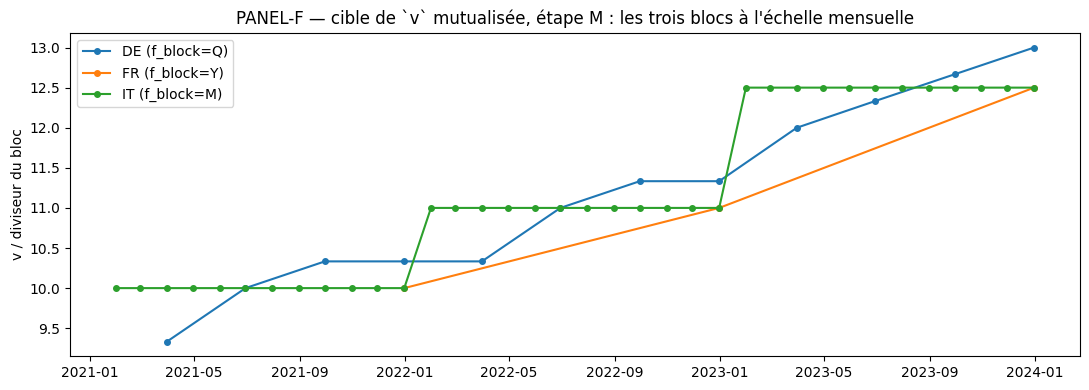

In [40]:
"""Superposition des trois blocs, une fois mis à l'échelle mensuelle (étape M)."""
step_M = next(s for s in PF.imputation_plan_
              if s.pred_freq_label == "M" and s.var_name == "v")
model = step_M.model
ent_keys = entities_of(model.fit_X_.index)
dates = [k[-1] for k in model.fit_X_.index]

fig, ax = plt.subplots(figsize=(11, 4))
for ent in sorted(set(ent_keys), key=str):
    sel = [i for i, e in enumerate(ent_keys) if e == ent]
    d = [dates[i] for i in sel]
    ax.plot(d, model.fit_y_.iloc[sel].to_numpy(), marker="o", ms=4,
            label=f"{ent[0]} (f_block={dict(step_M.training_blocks).get(ent)})")
ax.set_title("PANEL-F — cible de `v` mutualisée, étape M : les trois blocs à l'échelle mensuelle")
ax.set_ylabel("v / diviseur du bloc")
ax.legend()
fig.tight_layout()
plt.show()

In [41]:
"""IT alimente l'entraînement sans JAMAIS être réécrite."""
imp_pf = HighFrequencyImputer(target_frequency="M", estimator=LinearRegression(),
                              covariate_strategy="interpolate", keep_lower_frequencies=False,
                              impute_intermediate_frequencies=False)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    out_pf = imp_pf.fit_transform(PANEL_F.copy())
prov_pf = imp_pf.imputation_provenance_["v"]
prov_pf_str = prov_pf.map(lambda x: x.value if hasattr(x, "value") else "—")
print("provenance de `v` par entité :")
print(prov_pf_str.groupby(level=0).value_counts().to_string())
it_input = PANEL_F.loc["IT", "v"]
it_output = out_pf.loc["IT", "v"]
print("\nIT : cellules de `v` inchangées entre entrée et sortie :",
      np.allclose(it_input.to_numpy(), it_output.to_numpy(), equal_nan=True))

provenance de `v` par entité :
country  v                    
DE       model_on_interpolated    36
FR       model_on_interpolated    36
IT       original                 36

IT : cellules de `v` inchangées entre entrée et sortie : True


In [42]:
"""Comptage comparé : 51 lignes mutualisées à chaque étape contre 3 sans mutualisation."""
mut = fit_spy(PANEL_F, covariate_strategy="interpolate",
              impute_intermediate_frequencies="covariates_only")
mut_rows = {(s.pred_freq_label, s.var_name): len(s.model.fit_y_)
            for s in mut.imputation_plan_ if s.var_name == "v" and not s.is_fallback}
print("PANEL-F, jeu MUTUALISÉ  — lignes de y_train de `v` par étape :", mut_rows)

# Sans mutualisation : restreindre le jeu à la seule entité FR (PAS d'ancienne
# classe — supprimée au prompt 16).
solo = fit_spy(PANEL_F.loc[["FR"]], covariate_strategy="interpolate",
               impute_intermediate_frequencies="covariates_only")
solo_rows = {(s.pred_freq_label, s.var_name): len(s.model.fit_y_)
             for s in solo.imputation_plan_ if s.var_name == "v" and not s.is_fallback}
print("PANEL-F restreint à FR  — lignes de y_train de `v` par étape :", solo_rows)

PANEL-F, jeu MUTUALISÉ  — lignes de y_train de `v` par étape : {('Q', 'v'): 51, ('M', 'v'): 51}
PANEL-F restreint à FR  — lignes de y_train de `v` par étape : {('Q', 'v'): 3, ('M', 'v'): 3}


**Mesure historique de `hfi` (archivée).** [SPEC] §1.5 rapporte que l'ancien
`HighFrequencyImputer` produisait, sur le même jeu, **9 lignes** de `y_train`
(3 `FR` + 3 `DE` + 3 `IT`) à **trois échelles différentes** — le coût de la
mutualisation sans le bénéfice. Cette classe étant supprimée (prompt 16), la
valeur est citée telle quelle, sans être reproduite. `hfi2` : **51 lignes
cohérentes** à toute étape, contre **3** sans mutualisation.

**Modèle partagé, recalages distincts.** Les deux étapes de plan `(M, v)`
(`FR` / `source_frequency='Y'` et `DE` / `source_frequency='Q'`) partagent
l'objet modèle et recalent sur des totaux différents.

In [43]:
mv = [s for s in PF.imputation_plan_ if s.pred_freq_label == "M" and s.var_name == "v"]
if len(mv) == 2:
    print("même objet modèle (is)      :", mv[0].model is mv[1].model)
    print("source_frequency / entities :",
          (mv[0].source_frequency, mv[0].entities), "|",
          (mv[1].source_frequency, mv[1].entities))

même objet modèle (is)      : True
source_frequency / entities : ('Q', (('DE',),)) | ('Y', (('FR',),))


## 11 — Rapport d'exécution

Le notebook s'exécute **intégralement**, sans cellule en erreur. Temps
d'exécution total ci-dessous.

In [44]:
elapsed = time.perf_counter() - NOTEBOOK_START
print(f"Notebook exécuté intégralement — aucune cellule en erreur.")
print(f"Temps d'exécution total (hors imports figés par le kernel) : {elapsed:.1f} s")

Notebook exécuté intégralement — aucune cellule en erreur.
Temps d'exécution total (hors imports figés par le kernel) : 72.8 s
